# Base vs LoRA Fine-Tuned Model Evaluation

This notebook evaluates the base Llama 3.1 8B model against the LoRA fine-tuned version using:
- 1000 random samples from the Alpaca dataset
- Claude Sonnet as an impartial judge (binary YES/NO scoring) via Vertex AI
- Throughput measurement (tokens/sec) for both models

**Prerequisites:**
- Both vLLM servers running via `./scripts/serve_k8s.sh`
- GCP authentication configured (`gcloud auth login`)
- `.venv` with `anthropic[vertex] openai datasets matplotlib seaborn pandas` installed

**Parameters (prompted on run):**
- `BASE_IP` — LoadBalancer IP of the base model vLLM server
- `LORA_IP` — LoadBalancer IP of the LoRA model vLLM server
- `GCP_PROJECT_ID` — GCP project ID for Vertex AI (or set `ANTHROPIC_VERTEX_PROJECT_ID`)
- `GCP_REGION` — GCP region for Vertex AI (default: `europe-west1`)

**Checkpointing:** Each step saves results to `results/`. If execution fails mid-way, re-running a step will resume from the checkpoint automatically.

In [1]:
!pip install -q 'anthropic[vertex]' openai datasets matplotlib seaborn pandas


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


## 1. Configuration

In [6]:
import os
import json

# Prompt for required parameters
BASE_IP = os.environ.get("BASE_IP") or input("Base model LoadBalancer IP: ").strip()
LORA_IP = os.environ.get("LORA_IP") or input("LoRA model LoadBalancer IP: ").strip()
GCP_PROJECT_ID = os.environ.get("ANTHROPIC_VERTEX_PROJECT_ID") or input("GCP Project ID for Vertex AI: ").strip()
GCP_REGION = os.environ.get("ANTHROPIC_VERTEX_REGION", "us-east5")

BASE_URL = f"http://{BASE_IP}:8000"
LORA_URL = f"http://{LORA_IP}:8000"

BASE_MODEL_NAME = "/mnt/data/Llama-3.1-8B"
LORA_MODEL_NAME = "lora-adapter"

NUM_SAMPLES = 1000
MAX_TOKENS = 512
TEMPERATURE = 0.1
SEED = 42
PARALLEL_WORKERS = 4
JUDGE_DELAY = 1.0

RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

config = {
    "base_url": BASE_URL, "lora_url": LORA_URL,
    "num_samples": NUM_SAMPLES, "max_tokens": MAX_TOKENS,
    "temperature": TEMPERATURE, "seed": SEED,
    "judge_model": "claude-sonnet-4-6", "judge_provider": "vertex-ai",
}
with open(f"{RESULTS_DIR}/config.json", "w") as f:
    json.dump(config, f, indent=2)

print(f"Base URL:    {BASE_URL}")
print(f"LoRA URL:    {LORA_URL}")
print(f"GCP Project: {GCP_PROJECT_ID}")
print(f"GCP Region:  {GCP_REGION}")
print(f"Samples:     {NUM_SAMPLES}")
print(f"Workers:     {PARALLEL_WORKERS}")
print(f"Judge delay: {JUDGE_DELAY}s")

Base URL:    http://X:8000
LoRA URL:    http://Y:8000
GCP Project: itpc-gcp-global-revenue-claude
GCP Region:  us-east5
Samples:     1000
Workers:     4
Judge delay: 1.0s


## 2. Load and Sample Dataset

In [7]:
import random

EVAL_DATA = "../dataset/eval/alpaca_eval.json"
SAMPLES_FILE = f"{RESULTS_DIR}/samples.json"

if os.path.exists(SAMPLES_FILE):
    with open(SAMPLES_FILE) as f:
        samples = json.load(f)
    print(f"Loaded {len(samples)} samples from checkpoint: {SAMPLES_FILE}")
else:
    with open(EVAL_DATA) as f:
        eval_data = json.load(f)
    rng = random.Random(SEED)
    samples = rng.sample(eval_data, min(NUM_SAMPLES, len(eval_data)))
    with open(SAMPLES_FILE, "w") as f:
        json.dump(samples, f)
    print(f"Sampled {len(samples)} from {len(eval_data)} eval examples (saved to {SAMPLES_FILE})")

print(f"\nExample:")
print(f"  Instruction: {samples[0]['instruction'][:100]}...")
print(f"  Input:       {samples[0].get('input', '')[:100]}")
print(f"  Output:      {samples[0]['output'][:100]}...")

Loaded 1000 samples from checkpoint: results/samples.json

Example:
  Instruction: To complete the analogy, write the missing word....
  Input:       Gasoline : Car::
  Output:      Gasoline : Car :: Electricity : Electric Vehicle...


## 3. Query Both Models

### Smoke Test — Single Sample Demo

Quick sanity check: query both models with one instruction where the fine-tuned model should clearly outperform the base model. Responses are streamed token-by-token.

In [4]:
from openai import OpenAI

base_client_smoke = OpenAI(api_key="EMPTY", base_url=f"{BASE_URL}/v1")
lora_client_smoke = OpenAI(api_key="EMPTY", base_url=f"{LORA_URL}/v1")

instruction = "How can I stay organized?"
smoke_prompt = f"### Instruction:\n{instruction}\n\n### Response:\n"

print(f"Prompt: {instruction}")

for label, client, model in [
    ("BASE MODEL", base_client_smoke, BASE_MODEL_NAME),
    ("LORA FINE-TUNED", lora_client_smoke, LORA_MODEL_NAME),
]:
    print(f"\n{'='*60}")
    print(f"  {label}")
    print(f"{'='*60}\n")
    stream = client.completions.create(
        model=model,
        prompt=smoke_prompt,
        max_tokens=256,
        temperature=0.1,
        stream=True,
    )
    for chunk in stream:
        token = chunk.choices[0].text
        if token:
            print(token, end="", flush=True)
    print("\n")

Prompt: How can I stay organized?

  BASE MODEL

I can stay organized by using a planner, a calendar, and a to-do list. I can also stay organized by using a filing system and a task management app. I can also stay organized by using a system of folders and subfolders to keep track of my files and documents. I can also stay organized by using a system of labels and tags to keep track of my tasks and projects. I can also stay organized by using a system of reminders and alerts to keep track of my deadlines and appointments. I can also stay organized by using a system of checklists and to-do lists to keep track of my tasks and projects. I can also stay organized by using a system of prioritization and delegation to keep track of my tasks and projects. I can also stay organized by using a system of time management and scheduling to keep track of my tasks and projects. I can also stay organized by using a system of goal setting and tracking to keep track of my tasks and projects. I can also

In [5]:
import time
from concurrent.futures import ThreadPoolExecutor, as_completed
from openai import OpenAI

base_client = OpenAI(api_key="EMPTY", base_url=f"{BASE_URL}/v1")
lora_client = OpenAI(api_key="EMPTY", base_url=f"{LORA_URL}/v1")


def format_prompt(instruction, input_text=""):
    if input_text:
        return f"### Instruction:\n{instruction}\n\n### Input:\n{input_text}\n\n### Response:\n"
    return f"### Instruction:\n{instruction}\n\n### Response:\n"


def query_model(client, model_name, instruction, input_text=""):
    prompt = format_prompt(instruction, input_text)
    start = time.time()
    response = client.completions.create(
        model=model_name,
        prompt=prompt,
        max_tokens=MAX_TOKENS,
        temperature=TEMPERATURE,
    )
    elapsed = time.time() - start
    text = response.choices[0].text.strip()
    tokens = response.usage.completion_tokens
    return text, elapsed, tokens


def query_sample(i, sample):
    instruction = sample["instruction"]
    input_text = sample.get("input", "") or ""
    result = {
        "index": i,
        "instruction": instruction,
        "input": input_text,
        "expected": sample.get("output", ""),
    }
    try:
        text, elapsed, tokens = query_model(base_client, BASE_MODEL_NAME, instruction, input_text)
        result["base_response"] = text
        result["base_time"] = elapsed
        result["base_tokens"] = tokens
    except Exception as e:
        result["base_response"] = ""
        result["base_time"] = 0
        result["base_tokens"] = 0
        result["base_error"] = str(e)

    try:
        text, elapsed, tokens = query_model(lora_client, LORA_MODEL_NAME, instruction, input_text)
        result["lora_response"] = text
        result["lora_time"] = elapsed
        result["lora_tokens"] = tokens
    except Exception as e:
        result["lora_response"] = ""
        result["lora_time"] = 0
        result["lora_tokens"] = 0
        result["lora_error"] = str(e)

    return result

In [6]:
QUERY_CHECKPOINT = f"{RESULTS_DIR}/query_results.json"
SAMPLES_FILE = f"{RESULTS_DIR}/samples.json"

# Load samples from checkpoint if not in memory
if "samples" not in dir() or not samples:
    assert os.path.exists(SAMPLES_FILE), f"Run step 2 first — {SAMPLES_FILE} not found"
    with open(SAMPLES_FILE) as f:
        samples = json.load(f)
    print(f"Loaded {len(samples)} samples from {SAMPLES_FILE}")

if os.path.exists(QUERY_CHECKPOINT):
    with open(QUERY_CHECKPOINT) as f:
        results = json.load(f)
    completed_indices = {r["index"] for r in results}
    remaining = [(i, s) for i, s in enumerate(samples) if i not in completed_indices]
    print(f"Resuming from checkpoint: {len(results)} done, {len(remaining)} remaining")
else:
    results = []
    remaining = list(enumerate(samples))
    print(f"Starting fresh: {len(remaining)} samples to query")

if remaining:
    print(f"\nQuerying both models ({PARALLEL_WORKERS} workers)...\n")
    start_time = time.time()
    total_target = len(remaining) + len(results)

    with ThreadPoolExecutor(max_workers=PARALLEL_WORKERS) as executor:
        futures = {executor.submit(query_sample, i, s): i for i, s in remaining}
        for future in as_completed(futures):
            result = future.result()
            results.append(result)
            done = len(results)
            if done % 50 == 0 or done == total_target:
                elapsed = time.time() - start_time
                results.sort(key=lambda x: x["index"])
                with open(QUERY_CHECKPOINT, "w") as f:
                    json.dump(results, f)
                print(f"  [{done:4d}/{total_target}] {elapsed:.0f}s — checkpointed")

    results.sort(key=lambda x: x["index"])
    with open(QUERY_CHECKPOINT, "w") as f:
        json.dump(results, f)
    print(f"\nDone. Total query time: {time.time() - start_time:.1f}s")
else:
    print("All samples already queried.")

print(f"Saved: {QUERY_CHECKPOINT} ({len(results)} results)")

Starting fresh: 1000 samples to query

Querying both models (4 workers)...

  [  50/1000] 67s — checkpointed
  [ 100/1000] 153s — checkpointed
  [ 150/1000] 228s — checkpointed
  [ 200/1000] 310s — checkpointed
  [ 250/1000] 400s — checkpointed
  [ 300/1000] 494s — checkpointed
  [ 350/1000] 590s — checkpointed
  [ 400/1000] 677s — checkpointed
  [ 450/1000] 768s — checkpointed
  [ 500/1000] 863s — checkpointed
  [ 550/1000] 944s — checkpointed
  [ 600/1000] 1032s — checkpointed
  [ 650/1000] 1131s — checkpointed
  [ 700/1000] 1210s — checkpointed
  [ 750/1000] 1287s — checkpointed
  [ 800/1000] 1388s — checkpointed
  [ 850/1000] 1484s — checkpointed
  [ 900/1000] 1559s — checkpointed
  [ 950/1000] 1659s — checkpointed
  [1000/1000] 1752s — checkpointed

Done. Total query time: 1752.2s
Saved: results/query_results.json (1000 results)


## 4. Claude Sonnet Judge (Vertex AI)

Uses Claude Sonnet via GCP Vertex AI as an impartial judge. Rate-limited with delays and retries. Results are checkpointed per-sample so interrupted runs can resume.

In [7]:
import anthropic
import threading

judge_client = anthropic.AnthropicVertex(
    project_id=GCP_PROJECT_ID,
    region=GCP_REGION,
)
JUDGE_MODEL = "claude-sonnet-4-6"

_rate_lock = threading.Lock()

JUDGE_SYSTEM = """You are an impartial judge evaluating AI model responses.
Given an instruction (and optional input) and the model's response, decide whether
the response is correct, relevant, and helpful.

Rules:
- Answer ONLY "YES" or "NO".
- YES means the response correctly addresses the instruction, is factually reasonable,
  and provides a useful answer.
- NO means the response is wrong, irrelevant, incomplete, or nonsensical."""

JUDGE_TEMPLATE = """### Instruction:
{instruction}

{input_section}### Model Response:
{response}

Is this response correct, relevant, and helpful? Answer YES or NO."""


def judge_response(instruction, input_text, response):
    if not response:
        return 0
    input_section = f"### Input:\n{input_text}\n\n" if input_text else ""
    user_msg = JUDGE_TEMPLATE.format(
        instruction=instruction,
        input_section=input_section,
        response=response,
    )
    max_retries = 5
    for attempt in range(max_retries):
        try:
            with _rate_lock:
                time.sleep(JUDGE_DELAY)
            result = judge_client.messages.create(
                model=JUDGE_MODEL,
                max_tokens=5,
                temperature=0,
                system=JUDGE_SYSTEM,
                messages=[{"role": "user", "content": user_msg}],
            )
            answer = result.content[0].text.strip().upper()
            return 1 if answer.startswith("YES") else 0
        except anthropic.RateLimitError:
            wait = 2 ** attempt * 5
            print(f"    Rate limited, waiting {wait}s (attempt {attempt+1}/{max_retries})")
            time.sleep(wait)
        except Exception as e:
            if "rate" in str(e).lower() or "429" in str(e):
                wait = 2 ** attempt * 5
                print(f"    Rate limited, waiting {wait}s (attempt {attempt+1}/{max_retries})")
                time.sleep(wait)
            else:
                print(f"    Judge error: {e}")
                return 0
    print(f"    Max retries exceeded")
    return 0


def judge_sample(result):
    result["base_score"] = judge_response(
        result["instruction"], result["input"], result.get("base_response", "")
    )
    result["lora_score"] = judge_response(
        result["instruction"], result["input"], result.get("lora_response", "")
    )
    return result

print(f"Judge ready: {JUDGE_MODEL} via Vertex AI ({GCP_PROJECT_ID} / {GCP_REGION})")

Judge ready: claude-sonnet-4-6 via Vertex AI (itpc-gcp-global-revenue-claude / us-east5)


In [8]:
import time
import json
import os
from concurrent.futures import ThreadPoolExecutor, as_completed

QUERY_CHECKPOINT = f"{RESULTS_DIR}/query_results.json"
JUDGE_CHECKPOINT = f"{RESULTS_DIR}/judge_results.json"

# Load query results from checkpoint (so step 3 can be skipped)
assert os.path.exists(QUERY_CHECKPOINT), f"Run step 3 first — {QUERY_CHECKPOINT} not found"
with open(QUERY_CHECKPOINT) as f:
    results = json.load(f)
print(f"Loaded {len(results)} query results from {QUERY_CHECKPOINT}")

if os.path.exists(JUDGE_CHECKPOINT):
    with open(JUDGE_CHECKPOINT) as f:
        judged_results = json.load(f)
    judged_indices = {r["index"] for r in judged_results if "base_score" in r}
    remaining_judge = [r for r in results if r["index"] not in judged_indices]
    print(f"Resuming from checkpoint: {len(judged_results)} judged, {len(remaining_judge)} remaining")
else:
    judged_results = []
    remaining_judge = list(results)
    print(f"Starting fresh: {len(remaining_judge)} samples to judge")

if remaining_judge:
    print(f"\nJudging with Claude Sonnet ({PARALLEL_WORKERS} workers, {JUDGE_DELAY}s delay)...\n")
    start_time = time.time()
    total_target = len(remaining_judge) + len(judged_results)
    newly_judged = 0

    with ThreadPoolExecutor(max_workers=PARALLEL_WORKERS) as executor:
        futures = {executor.submit(judge_sample, dict(r)): r["index"] for r in remaining_judge}
        for future in as_completed(futures):
            result = future.result()
            judged_results.append(result)
            newly_judged += 1
            done = len(judged_results)
            if newly_judged % 25 == 0 or done == total_target:
                elapsed = time.time() - start_time
                base_acc = sum(r.get("base_score", 0) for r in judged_results) / done * 100
                lora_acc = sum(r.get("lora_score", 0) for r in judged_results) / done * 100
                judged_results.sort(key=lambda x: x["index"])
                with open(JUDGE_CHECKPOINT, "w") as f:
                    json.dump(judged_results, f)
                print(f"  [{done:4d}/{total_target}] Base: {base_acc:.1f}% | LoRA: {lora_acc:.1f}% | {elapsed:.0f}s — checkpointed")

    judged_results.sort(key=lambda x: x["index"])
    with open(JUDGE_CHECKPOINT, "w") as f:
        json.dump(judged_results, f)
    print(f"\nJudging complete. Time: {time.time() - start_time:.1f}s")
else:
    print("All samples already judged.")

print(f"Saved: {JUDGE_CHECKPOINT} ({len(judged_results)} results)")

Loaded 1000 query results from results/query_results.json
Starting fresh: 1000 samples to judge

Judging with Claude Sonnet (4 workers, 1.0s delay)...

  [  25/1000] Base: 56.0% | LoRA: 76.0% | 54s — checkpointed
  [  50/1000] Base: 54.0% | LoRA: 76.0% | 103s — checkpointed
  [  75/1000] Base: 54.7% | LoRA: 81.3% | 153s — checkpointed
  [ 100/1000] Base: 56.0% | LoRA: 85.0% | 203s — checkpointed
  [ 125/1000] Base: 54.4% | LoRA: 84.8% | 255s — checkpointed
  [ 150/1000] Base: 53.3% | LoRA: 84.7% | 304s — checkpointed
  [ 175/1000] Base: 52.0% | LoRA: 82.9% | 353s — checkpointed
  [ 200/1000] Base: 51.5% | LoRA: 83.0% | 405s — checkpointed
  [ 225/1000] Base: 50.7% | LoRA: 83.1% | 455s — checkpointed
  [ 250/1000] Base: 50.8% | LoRA: 82.8% | 505s — checkpointed
  [ 275/1000] Base: 51.3% | LoRA: 82.9% | 554s — checkpointed
  [ 300/1000] Base: 50.0% | LoRA: 82.3% | 604s — checkpointed
  [ 325/1000] Base: 49.2% | LoRA: 82.2% | 657s — checkpointed
  [ 350/1000] Base: 50.3% | LoRA: 81.7% | 7

## 5. Save Results

In [9]:
import pandas as pd

df = pd.DataFrame(judged_results)

df.to_csv(f"{RESULTS_DIR}/eval_details.csv", index=False)
df.to_json(f"{RESULTS_DIR}/eval_details.json", orient="records", indent=2)

summary = {
    "num_samples": len(df),
    "judge_model": JUDGE_MODEL,
    "judge_provider": "vertex-ai",
    "base_accuracy": round(df["base_score"].mean() * 100, 2),
    "lora_accuracy": round(df["lora_score"].mean() * 100, 2),
    "improvement": round((df["lora_score"].mean() - df["base_score"].mean()) * 100, 2),
    "base_avg_tokens": round(df["base_tokens"].mean(), 1),
    "lora_avg_tokens": round(df["lora_tokens"].mean(), 1),
    "base_avg_latency_s": round(df["base_time"].mean(), 3),
    "lora_avg_latency_s": round(df["lora_time"].mean(), 3),
    "base_throughput_tok_s": round(df["base_tokens"].sum() / df["base_time"].sum(), 1),
    "lora_throughput_tok_s": round(df["lora_tokens"].sum() / df["lora_time"].sum(), 1),
}

with open(f"{RESULTS_DIR}/eval_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("Saved to results/:")
print(f"  eval_details.csv   ({len(df)} rows)")
print(f"  eval_details.json  ({len(df)} records)")
print(f"  eval_summary.json")
print(f"\nSummary:")
for k, v in summary.items():
    print(f"  {k}: {v}")

Saved to results/:
  eval_details.csv   (1000 rows)
  eval_details.json  (1000 records)
  eval_summary.json

Summary:
  num_samples: 1000
  judge_model: claude-sonnet-4-6
  judge_provider: vertex-ai
  base_accuracy: 49.4
  lora_accuracy: 83.5
  improvement: 34.1
  base_avg_tokens: 242.8
  lora_avg_tokens: 52.0
  base_avg_latency_s: 5.596
  lora_avg_latency_s: 1.395
  base_throughput_tok_s: 43.4
  lora_throughput_tok_s: 37.3


## 6. Accuracy Analysis

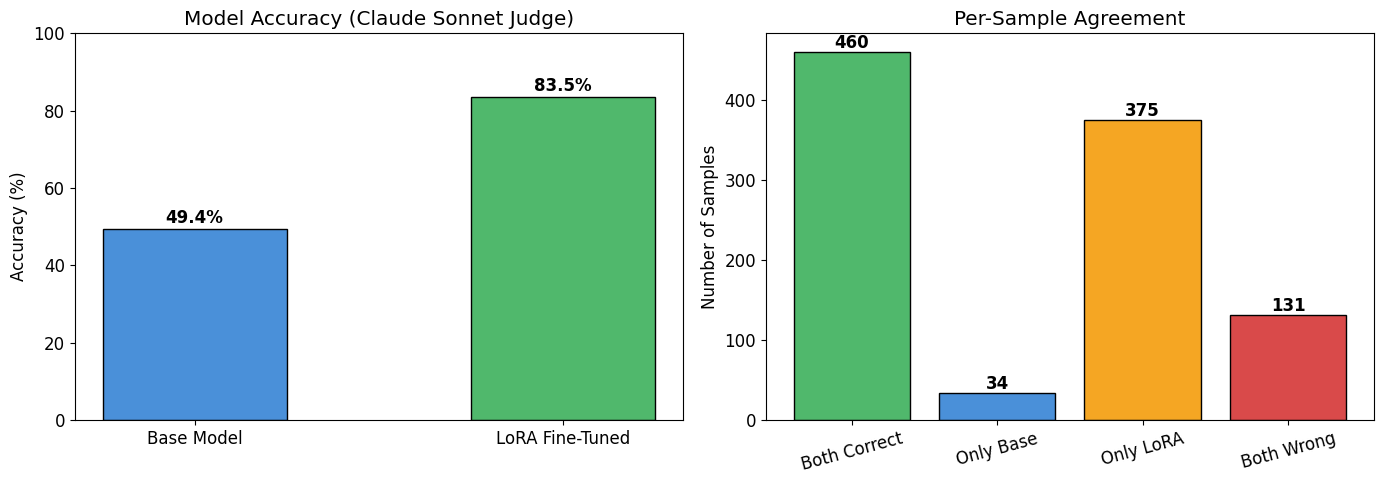

Saved: results/accuracy_comparison.png


In [10]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({"font.size": 12})

base_acc = df["base_score"].mean() * 100
lora_acc = df["lora_score"].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: accuracy comparison
bars = axes[0].bar(["Base Model", "LoRA Fine-Tuned"], [base_acc, lora_acc],
                   color=["#4a90d9", "#50b86c"], width=0.5, edgecolor="black")
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_title("Model Accuracy (Claude Sonnet Judge)")
axes[0].set_ylim(0, 100)
for bar, val in zip(bars, [base_acc, lora_acc]):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5,
                 f"{val:.1f}%", ha="center", fontweight="bold")

# Stacked bar: per-sample agreement
both_correct = ((df["base_score"] == 1) & (df["lora_score"] == 1)).sum()
only_base = ((df["base_score"] == 1) & (df["lora_score"] == 0)).sum()
only_lora = ((df["base_score"] == 0) & (df["lora_score"] == 1)).sum()
both_wrong = ((df["base_score"] == 0) & (df["lora_score"] == 0)).sum()

categories = ["Both Correct", "Only Base", "Only LoRA", "Both Wrong"]
values = [both_correct, only_base, only_lora, both_wrong]
colors = ["#50b86c", "#4a90d9", "#f5a623", "#d94a4a"]

bars2 = axes[1].bar(categories, values, color=colors, edgecolor="black")
axes[1].set_ylabel("Number of Samples")
axes[1].set_title("Per-Sample Agreement")
axes[1].tick_params(axis="x", rotation=15)
for bar, val in zip(bars2, values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                 str(val), ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/accuracy_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {RESULTS_DIR}/accuracy_comparison.png")

## 7. Confusion Matrix

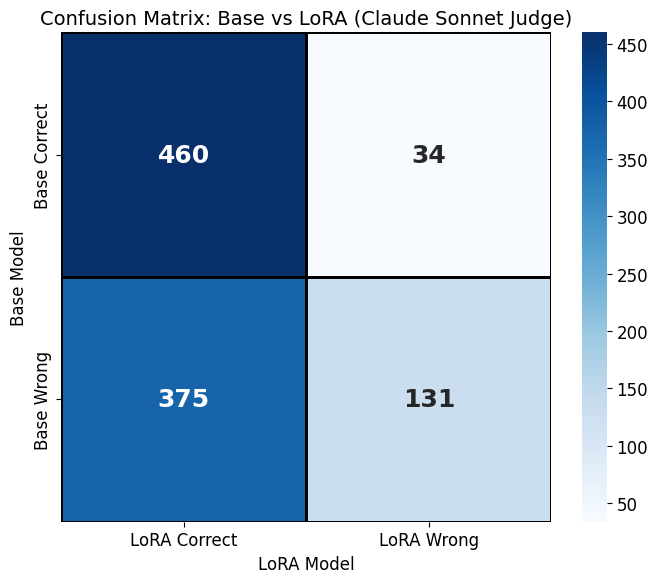

Saved: results/confusion_matrix.png

Interpretation:
  Both correct:        460 (46.0%)
  Only base correct:    34 (3.4%) — LoRA regression
  Only LoRA correct:   375 (37.5%) — LoRA improvement
  Both wrong:          131 (13.1%)


In [11]:
import seaborn as sns
import numpy as np

confusion = np.array([
    [both_correct, only_base],
    [only_lora, both_wrong],
])

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    confusion,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["LoRA Correct", "LoRA Wrong"],
    yticklabels=["Base Correct", "Base Wrong"],
    linewidths=1,
    linecolor="black",
    annot_kws={"size": 18, "fontweight": "bold"},
    ax=ax,
)
ax.set_title("Confusion Matrix: Base vs LoRA (Claude Sonnet Judge)", fontsize=14)
ax.set_xlabel("LoRA Model", fontsize=12)
ax.set_ylabel("Base Model", fontsize=12)

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {RESULTS_DIR}/confusion_matrix.png")
print(f"\nInterpretation:")
print(f"  Both correct:       {both_correct:4d} ({both_correct/len(df)*100:.1f}%)")
print(f"  Only base correct:  {only_base:4d} ({only_base/len(df)*100:.1f}%) — LoRA regression")
print(f"  Only LoRA correct:  {only_lora:4d} ({only_lora/len(df)*100:.1f}%) — LoRA improvement")
print(f"  Both wrong:         {both_wrong:4d} ({both_wrong/len(df)*100:.1f}%)")

## 8. Throughput Analysis

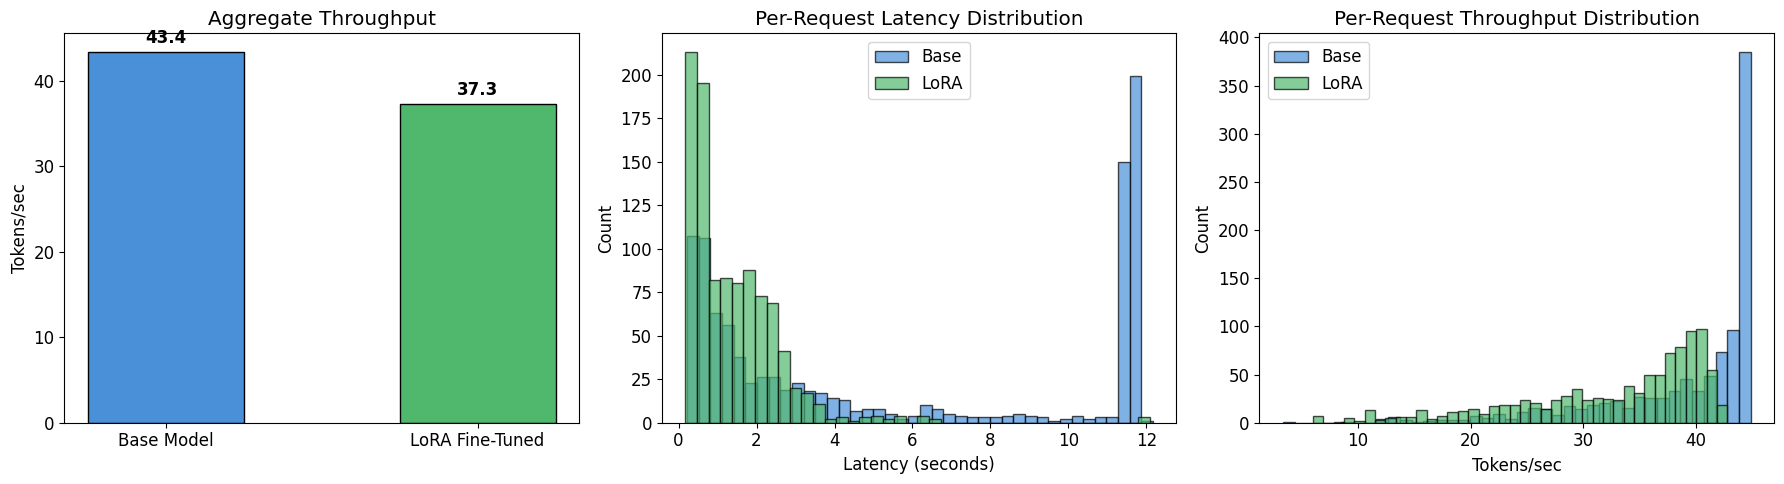

Saved: results/throughput_analysis.png

Throughput Summary:
  Base:  43.4 tok/s (avg latency: 5.596s, p95: 11.652s)
  LoRA:  37.3 tok/s (avg latency: 1.395s, p95: 3.213s)
  Overhead: -14.0% throughput change with LoRA


In [12]:
base_tok_s = df["base_tokens"].sum() / df["base_time"].sum()
lora_tok_s = df["lora_tokens"].sum() / df["lora_time"].sum()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Throughput bar chart
bars = axes[0].bar(["Base Model", "LoRA Fine-Tuned"], [base_tok_s, lora_tok_s],
                   color=["#4a90d9", "#50b86c"], width=0.5, edgecolor="black")
axes[0].set_ylabel("Tokens/sec")
axes[0].set_title("Aggregate Throughput")
for bar, val in zip(bars, [base_tok_s, lora_tok_s]):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                 f"{val:.1f}", ha="center", fontweight="bold")

# Latency distribution
axes[1].hist(df["base_time"], bins=40, alpha=0.7, label="Base", color="#4a90d9", edgecolor="black")
axes[1].hist(df["lora_time"], bins=40, alpha=0.7, label="LoRA", color="#50b86c", edgecolor="black")
axes[1].set_xlabel("Latency (seconds)")
axes[1].set_ylabel("Count")
axes[1].set_title("Per-Request Latency Distribution")
axes[1].legend()

# Per-request throughput (tokens/sec)
base_per_req = df["base_tokens"] / df["base_time"].replace(0, float("nan"))
lora_per_req = df["lora_tokens"] / df["lora_time"].replace(0, float("nan"))
axes[2].hist(base_per_req.dropna(), bins=40, alpha=0.7, label="Base", color="#4a90d9", edgecolor="black")
axes[2].hist(lora_per_req.dropna(), bins=40, alpha=0.7, label="LoRA", color="#50b86c", edgecolor="black")
axes[2].set_xlabel("Tokens/sec")
axes[2].set_ylabel("Count")
axes[2].set_title("Per-Request Throughput Distribution")
axes[2].legend()

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/throughput_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {RESULTS_DIR}/throughput_analysis.png")
print(f"\nThroughput Summary:")
print(f"  Base:  {base_tok_s:.1f} tok/s (avg latency: {df['base_time'].mean():.3f}s, p95: {df['base_time'].quantile(0.95):.3f}s)")
print(f"  LoRA:  {lora_tok_s:.1f} tok/s (avg latency: {df['lora_time'].mean():.3f}s, p95: {df['lora_time'].quantile(0.95):.3f}s)")
print(f"  Overhead: {(lora_tok_s/base_tok_s - 1)*100:+.1f}% throughput change with LoRA")

## 8.5 Automated Metrics (ROUGE-L & BERTScore)

Reference-based metrics computed locally (CPU-only, no API calls). These complement the Claude judge by measuring:
- **ROUGE-L**: Longest common subsequence overlap with the reference answer (surface-level similarity)
- **BERTScore**: Contextual embedding similarity using a pre-trained language model (semantic similarity)

In [4]:
!pip install -q rouge-score bert-score


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [9]:
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from rouge_score import rouge_scorer

RESULTS_DIR = "results"
JUDGE_CHECKPOINT = f"{RESULTS_DIR}/judge_results.json"

with open(JUDGE_CHECKPOINT) as f:
    judged_results = json.load(f)
df = pd.DataFrame(judged_results)
print(f"Loaded {len(df)} results from {JUDGE_CHECKPOINT}")

references = df["expected"].tolist()
base_responses = df["base_response"].fillna("").tolist()
lora_responses = df["lora_response"].fillna("").tolist()

# --- ROUGE-L ---
print("Computing ROUGE-L...")
scorer = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)

base_rouge = [scorer.score(ref, pred)["rougeL"].fmeasure for ref, pred in zip(references, base_responses)]
lora_rouge = [scorer.score(ref, pred)["rougeL"].fmeasure for ref, pred in zip(references, lora_responses)]

print(f"  Base ROUGE-L:  {np.mean(base_rouge):.4f} (median {np.median(base_rouge):.4f})")
print(f"  LoRA ROUGE-L:  {np.mean(lora_rouge):.4f} (median {np.median(lora_rouge):.4f})")

# --- BERTScore ---
# Monkey-patch bert_score to fix incompatibility with transformers 5.x
# (build_inputs_with_special_tokens was removed in transformers v5)
import bert_score.utils as _bsu

_original_sent_encode = _bsu.sent_encode
def _patched_sent_encode(tokenizer, sent):
    sent = sent.strip()
    if sent == "":
        return tokenizer.encode("", add_special_tokens=True)
    return _original_sent_encode(tokenizer, sent)
_bsu.sent_encode = _patched_sent_encode

from bert_score import score as bert_score_fn

print("\nComputing BERTScore (this may take a few minutes on CPU)...")
base_P, base_R, base_F1 = bert_score_fn(
    base_responses, references, lang="en", verbose=True, use_fast_tokenizer=True,
)
lora_P, lora_R, lora_F1 = bert_score_fn(
    lora_responses, references, lang="en", verbose=True, use_fast_tokenizer=True,
)

base_bert = base_F1.numpy()
lora_bert = lora_F1.numpy()

print(f"\n  Base BERTScore F1:  {base_bert.mean():.4f} (median {np.median(base_bert):.4f})")
print(f"  LoRA BERTScore F1:  {lora_bert.mean():.4f} (median {np.median(lora_bert):.4f})")

# Store in dataframe
df["base_rouge_l"] = base_rouge
df["lora_rouge_l"] = lora_rouge
df["base_bertscore"] = base_bert
df["lora_bertscore"] = lora_bert

df.to_csv(f"{RESULTS_DIR}/eval_details.csv", index=False)
df.to_json(f"{RESULTS_DIR}/eval_details.json", orient="records", indent=2)
print(f"\nUpdated {RESULTS_DIR}/eval_details.csv with ROUGE-L and BERTScore columns")

Loaded 1000 results from results/judge_results.json
Computing ROUGE-L...
  Base ROUGE-L:  0.2117 (median 0.1556)
  LoRA ROUGE-L:  0.4304 (median 0.3431)

Computing BERTScore (this may take a few minutes on CPU)...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


calculating scores...
computing bert embedding.


  0%|          | 0/31 [00:00<?, ?it/s]

...

calculating scores...
computing bert embedding.


  0%|          | 0/30 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/16 [00:00<?, ?it/s]

done in 90.84 seconds, 11.01 sentences/sec

  Base BERTScore F1:  0.8418 (median 0.8452)
  LoRA BERTScore F1:  0.9126 (median 0.9081)

Updated results/eval_details.csv with ROUGE-L and BERTScore columns


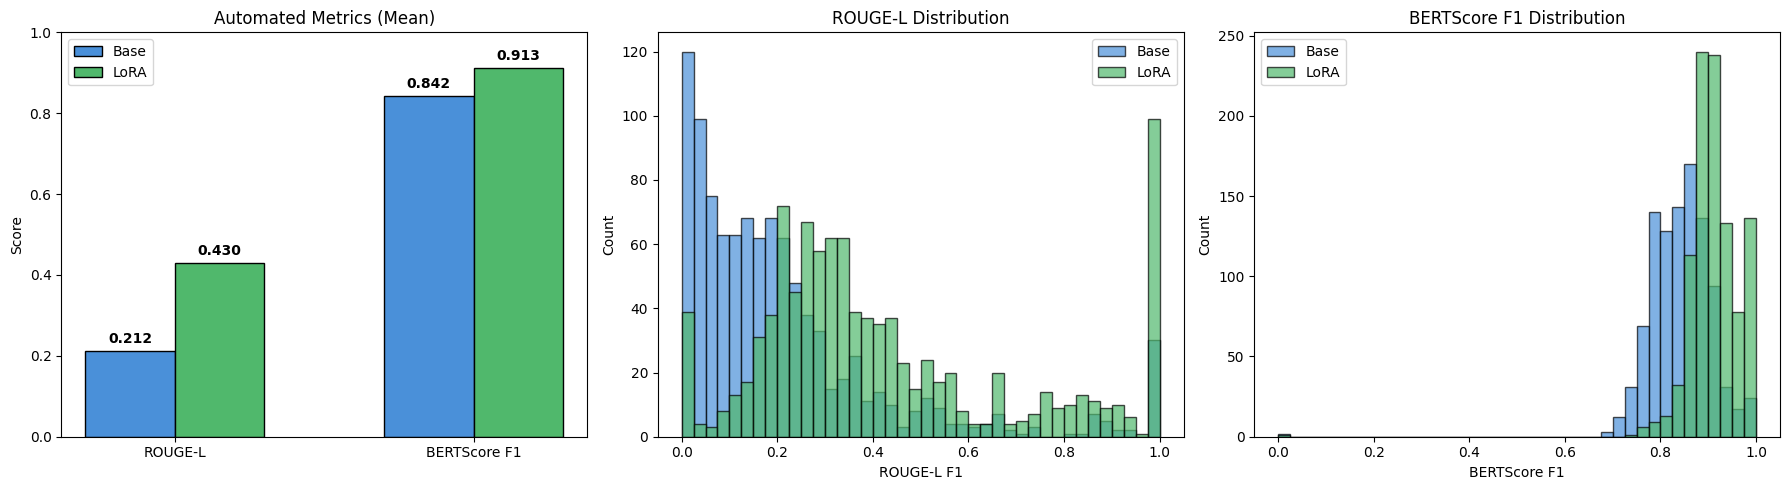

Saved: results/automated_metrics.png


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Bar chart: mean ROUGE-L and BERTScore
metrics = ["ROUGE-L", "BERTScore F1"]
base_vals = [np.mean(base_rouge), base_bert.mean()]
lora_vals = [np.mean(lora_rouge), lora_bert.mean()]

x = np.arange(len(metrics))
w = 0.3
bars1 = axes[0].bar(x - w/2, base_vals, w, label="Base", color="#4a90d9", edgecolor="black")
bars2 = axes[0].bar(x + w/2, lora_vals, w, label="LoRA", color="#50b86c", edgecolor="black")
axes[0].set_ylabel("Score")
axes[0].set_title("Automated Metrics (Mean)")
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].set_ylim(0, 1)
axes[0].legend()
for bar, val in zip(list(bars1) + list(bars2), base_vals + lora_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f"{val:.3f}", ha="center", fontweight="bold", fontsize=10)

# 2. ROUGE-L distribution
axes[1].hist(base_rouge, bins=40, alpha=0.7, label="Base", color="#4a90d9", edgecolor="black")
axes[1].hist(lora_rouge, bins=40, alpha=0.7, label="LoRA", color="#50b86c", edgecolor="black")
axes[1].set_xlabel("ROUGE-L F1")
axes[1].set_ylabel("Count")
axes[1].set_title("ROUGE-L Distribution")
axes[1].legend()

# 3. BERTScore distribution
axes[2].hist(base_bert, bins=40, alpha=0.7, label="Base", color="#4a90d9", edgecolor="black")
axes[2].hist(lora_bert, bins=40, alpha=0.7, label="LoRA", color="#50b86c", edgecolor="black")
axes[2].set_xlabel("BERTScore F1")
axes[2].set_ylabel("Count")
axes[2].set_title("BERTScore F1 Distribution")
axes[2].legend()

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/automated_metrics.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {RESULTS_DIR}/automated_metrics.png")

## 9. Summary Report

In [11]:
import json
import numpy as np
import pandas as pd

RESULTS_DIR = "results"

# Load all data from disk — no dependency on earlier cells
with open(f"{RESULTS_DIR}/judge_results.json") as f:
    df = pd.DataFrame(json.load(f))

with open(f"{RESULTS_DIR}/config.json") as f:
    config = json.load(f)

# Judge accuracy
base_acc = df["base_score"].mean() * 100
lora_acc = df["lora_score"].mean() * 100

# Agreement breakdown
both_correct = int(((df["base_score"] == 1) & (df["lora_score"] == 1)).sum())
only_base = int(((df["base_score"] == 1) & (df["lora_score"] == 0)).sum())
only_lora = int(((df["base_score"] == 0) & (df["lora_score"] == 1)).sum())
both_wrong = int(((df["base_score"] == 0) & (df["lora_score"] == 0)).sum())

# Throughput
base_tok_s = df["base_tokens"].sum() / df["base_time"].sum()
lora_tok_s = df["lora_tokens"].sum() / df["lora_time"].sum()

# Automated metrics (from eval_details.csv if available, else warn)
details_path = f"{RESULTS_DIR}/eval_details.csv"
has_auto_metrics = False
if pd.io.common.file_exists(details_path):
    details = pd.read_csv(details_path)
    if "base_rouge_l" in details.columns and "base_bertscore" in details.columns:
        has_auto_metrics = True
        base_rouge_mean = details["base_rouge_l"].mean()
        lora_rouge_mean = details["lora_rouge_l"].mean()
        base_bert_mean = details["base_bertscore"].mean()
        lora_bert_mean = details["lora_bertscore"].mean()

num_samples = len(df)
judge_model = config.get("judge_model", "claude-sonnet-4-6")

print("=" * 60)
print("EVALUATION REPORT")
print("=" * 60)
print(f"")
print(f"Dataset:     Alpaca ({num_samples} samples, seed={config.get('seed', 42)})")
print(f"Judge:       Claude Sonnet ({judge_model}) via Vertex AI")
print(f"Base Model:  Llama 3.1 8B")
print(f"LoRA Model:  Llama 3.1 8B + LoRA adapter (r=16, alpha=32)")
print(f"")
print(f"--- Judge Accuracy ---")
print(f"  Base:        {base_acc:.1f}%")
print(f"  LoRA:        {lora_acc:.1f}%")
print(f"  Improvement: {lora_acc - base_acc:+.1f}%")
if has_auto_metrics:
    print(f"")
    print(f"--- Automated Metrics ---")
    print(f"  ROUGE-L      Base: {base_rouge_mean:.4f}  |  LoRA: {lora_rouge_mean:.4f}  |  Delta: {lora_rouge_mean - base_rouge_mean:+.4f}")
    print(f"  BERTScore F1 Base: {base_bert_mean:.4f}  |  LoRA: {lora_bert_mean:.4f}  |  Delta: {lora_bert_mean - base_bert_mean:+.4f}")
print(f"")
print(f"--- Agreement ---")
print(f"  Both correct:       {both_correct:4d} ({both_correct/num_samples*100:.1f}%)")
print(f"  Only base correct:  {only_base:4d} ({only_base/num_samples*100:.1f}%)")
print(f"  Only LoRA correct:  {only_lora:4d} ({only_lora/num_samples*100:.1f}%)")
print(f"  Both wrong:         {both_wrong:4d} ({both_wrong/num_samples*100:.1f}%)")
print(f"")
print(f"--- Throughput ---")
print(f"  Base:  {base_tok_s:.1f} tok/s (avg {df['base_time'].mean():.3f}s, p95 {df['base_time'].quantile(0.95):.3f}s)")
print(f"  LoRA:  {lora_tok_s:.1f} tok/s (avg {df['lora_time'].mean():.3f}s, p95 {df['lora_time'].quantile(0.95):.3f}s)")
print(f"")
print(f"--- Output Files ---")
print(f"  {RESULTS_DIR}/eval_details.csv")
print(f"  {RESULTS_DIR}/eval_details.json")
print(f"  {RESULTS_DIR}/eval_summary.json")
print(f"  {RESULTS_DIR}/accuracy_comparison.png")
print(f"  {RESULTS_DIR}/confusion_matrix.png")
print(f"  {RESULTS_DIR}/throughput_analysis.png")
if has_auto_metrics:
    print(f"  {RESULTS_DIR}/automated_metrics.png")
print("=" * 60)

# Save eval_summary.json
summary = {
    "num_samples": num_samples,
    "judge_model": judge_model,
    "judge_provider": "vertex-ai",
    "base_accuracy": round(base_acc, 2),
    "lora_accuracy": round(lora_acc, 2),
    "improvement": round(lora_acc - base_acc, 2),
    "base_avg_tokens": round(float(df["base_tokens"].mean()), 1),
    "lora_avg_tokens": round(float(df["lora_tokens"].mean()), 1),
    "base_avg_latency_s": round(float(df["base_time"].mean()), 3),
    "lora_avg_latency_s": round(float(df["lora_time"].mean()), 3),
    "base_throughput_tok_s": round(float(base_tok_s), 1),
    "lora_throughput_tok_s": round(float(lora_tok_s), 1),
}
if has_auto_metrics:
    summary["base_rouge_l"] = round(float(base_rouge_mean), 4)
    summary["lora_rouge_l"] = round(float(lora_rouge_mean), 4)
    summary["base_bertscore_f1"] = round(float(base_bert_mean), 4)
    summary["lora_bertscore_f1"] = round(float(lora_bert_mean), 4)

with open(f"{RESULTS_DIR}/eval_summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print(f"\nSaved: {RESULTS_DIR}/eval_summary.json")

EVALUATION REPORT

Dataset:     Alpaca (1000 samples, seed=42)
Judge:       Claude Sonnet (claude-sonnet-4-6) via Vertex AI
Base Model:  Llama 3.1 8B
LoRA Model:  Llama 3.1 8B + LoRA adapter (r=16, alpha=32)

--- Judge Accuracy ---
  Base:        49.4%
  LoRA:        83.5%
  Improvement: +34.1%

--- Automated Metrics ---
  ROUGE-L      Base: 0.2117  |  LoRA: 0.4304  |  Delta: +0.2187
  BERTScore F1 Base: 0.8418  |  LoRA: 0.9126  |  Delta: +0.0708

--- Agreement ---
  Both correct:        460 (46.0%)
  Only base correct:    34 (3.4%)
  Only LoRA correct:   375 (37.5%)
  Both wrong:          131 (13.1%)

--- Throughput ---
  Base:  43.4 tok/s (avg 5.596s, p95 11.652s)
  LoRA:  37.3 tok/s (avg 1.395s, p95 3.213s)

--- Output Files ---
  results/eval_details.csv
  results/eval_details.json
  results/eval_summary.json
  results/accuracy_comparison.png
  results/confusion_matrix.png
  results/throughput_analysis.png
  results/automated_metrics.png

Saved: results/eval_summary.json
